In [7]:
# ============================================================
# CELL 1 — Setup: Upload Kaggle Key & Install Libraries
# ============================================================

# Step 1: Upload your kaggle.json file
from google.colab import files
print("📁 Please upload your kaggle.json file when the dialog opens...")
uploaded = files.upload()  # A file picker will appear — select kaggle.json

# Step 2: Move kaggle.json to the right location
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print("✅ kaggle.json configured successfully!")

# Step 3: Install / upgrade required libraries
print("\n📦 Installing libraries...")
import subprocess
subprocess.run(['pip', 'install', '-q', 'kaggle', 'pandas', 'numpy',
                'scikit-learn', 'tensorflow', 'matplotlib',
                'seaborn', 'ipykernel'], check=True)
print("✅ All libraries installed!")

# Step 4: Verify everything imported correctly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn
print(f"\n✅ TensorFlow version : {tf.__version__}")
print(f"✅ Pandas version     : {pd.__version__}")
print(f"✅ Scikit-learn version: {sklearn.__version__}")
print(f"✅ NumPy version      : {np.__version__}")

# Step 5: Check GPU
gpu_list = tf.config.list_physical_devices('GPU')
if gpu_list:
    print(f"\n🚀 GPU detected: {gpu_list[0].name} — training will be fast!")
else:
    print("\n⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU")

📁 Please upload your kaggle.json file when the dialog opens...


Saving kaggle.json to kaggle.json
✅ kaggle.json configured successfully!

📦 Installing libraries...
✅ All libraries installed!

✅ TensorFlow version : 2.20.0
✅ Pandas version     : 2.2.2
✅ Scikit-learn version: 1.6.1
✅ NumPy version      : 2.0.2

🚀 GPU detected: /physical_device:GPU:0 — training will be fast!


In [8]:
# ============================================================
# CELL 2 — Download Both Datasets from Kaggle
# ============================================================

import os

# Create a folder to store our datasets
os.makedirs('/content/datasets', exist_ok=True)
print("📂 Created /content/datasets folder\n")

# ── Dataset 1: CIC-Darknet2020 ──────────────────────────────
print("⬇️  Downloading Dataset 1: CIC-Darknet2020...")
os.system('kaggle datasets download -d dhoogla/cicdarknet2020 -p /content/datasets/darknet --unzip')
print("✅ Dataset 1 downloaded!\n")

# ── Dataset 2: Network Traffic Dataset ──────────────────────
print("⬇️  Downloading Dataset 2: Network Traffic Dataset...")
os.system('kaggle datasets download -d nameera06/network-traffic -p /content/datasets/nettraffic --unzip')
print("✅ Dataset 2 downloaded!\n")

# ── Check what files we got ──────────────────────────────────
print("=" * 50)
print("📁 Files in Dataset 1 (Darknet):")
for f in os.listdir('/content/datasets/darknet'):
    size = os.path.getsize(f'/content/datasets/darknet/{f}') / (1024*1024)
    print(f"   {f}  ({size:.1f} MB)")

print("\n📁 Files in Dataset 2 (Network Traffic):")
for f in os.listdir('/content/datasets/nettraffic'):
    size = os.path.getsize(f'/content/datasets/nettraffic/{f}') / (1024*1024)
    print(f"   {f}  ({size:.1f} MB)")

print("\n✅ Both datasets ready!")

📂 Created /content/datasets folder

⬇️  Downloading Dataset 1: CIC-Darknet2020...
✅ Dataset 1 downloaded!

⬇️  Downloading Dataset 2: Network Traffic Dataset...
✅ Dataset 2 downloaded!

📁 Files in Dataset 1 (Darknet):
   cicdarknet2020.parquet  (12.2 MB)

📁 Files in Dataset 2 (Network Traffic):
   Midterm_02_group.csv  (61.4 MB)

✅ Both datasets ready!


In [9]:
# ============================================================
# CELL 3 (FIXED) — Explore Both Datasets (First Look)
# ============================================================

import pandas as pd
import numpy as np
import os

# ── Load Dataset 1: CIC-Darknet2020 (PARQUET format) ────────
print("=" * 60)
print("DATASET 1 — CIC-Darknet2020")
print("=" * 60)

df1 = pd.read_parquet('/content/datasets/darknet/cicdarknet2020.parquet')

print(f"Shape            : {df1.shape[0]} rows × {df1.shape[1]} columns")
print(f"Memory usage     : {df1.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nAll column names:\n{list(df1.columns)}")
print(f"\nClass distribution:")
label_col1 = df1.columns[-1]
print(f"Label column     : '{label_col1}'")
print(df1[label_col1].value_counts())
print(f"\nMissing values   : {df1.isnull().sum().sum()}")
print(f"Duplicate rows   : {df1.duplicated().sum()}")
print(f"\nData types:\n{df1.dtypes.value_counts()}")
print(f"\nFirst 3 rows:\n{df1.head(3)}")

# ── Load Dataset 2: Network Traffic (CSV format) ─────────────
print("\n" + "=" * 60)
print("DATASET 2 — Network Traffic Dataset")
print("=" * 60)

df2 = pd.read_csv('/content/datasets/nettraffic/Midterm_02_group.csv')

print(f"Shape            : {df2.shape[0]} rows × {df2.shape[1]} columns")
print(f"Memory usage     : {df2.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nAll column names:\n{list(df2.columns)}")
print(f"\nClass distribution:")
label_col2 = df2.columns[-1]
print(f"Label column     : '{label_col2}'")
print(df2[label_col2].value_counts())
print(f"\nMissing values   : {df2.isnull().sum().sum()}")
print(f"Duplicate rows   : {df2.duplicated().sum()}")
print(f"\nData types:\n{df2.dtypes.value_counts()}")
print(f"\nFirst 3 rows:\n{df2.head(3)}")

print("\n✅ Exploration complete! Copy the full output and share it.")

DATASET 1 — CIC-Darknet2020
Shape            : 103121 rows × 79 columns
Memory usage     : 23.6 MB

All column names:
['Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RS

In [10]:
# ============================================================
# CELL 4 — Download Better Dataset 2
# ============================================================
import os

print("⬇️  Downloading Dataset 2 (replacement): Network Traffic Dataset by ravikumargattu...")
os.makedirs('/content/datasets/nettraffic2', exist_ok=True)
os.system('kaggle datasets download -d ravikumargattu/network-traffic-dataset -p /content/datasets/nettraffic2 --unzip')

print("\n📁 Files downloaded:")
for f in os.listdir('/content/datasets/nettraffic2'):
    size = os.path.getsize(f'/content/datasets/nettraffic2/{f}') / (1024*1024)
    print(f"   {f}  ({size:.1f} MB)")

⬇️  Downloading Dataset 2 (replacement): Network Traffic Dataset by ravikumargattu...

📁 Files downloaded:
   Midterm_53_group.csv  (52.9 MB)
   output1.csv  (20.0 MB)


In [11]:
# ============================================================
# CELL 5 — Explore New Dataset 2
# ============================================================
import pandas as pd
import os

path = '/content/datasets/nettraffic2'
files = os.listdir(path)
print(f"Files: {files}")

# Load first CSV found
csv_files = [f for f in files if f.endswith('.csv')]
df2 = pd.read_csv(f'{path}/{csv_files[0]}')

print(f"\nShape: {df2.shape[0]} rows × {df2.shape[1]} columns")
print(f"\nAll columns:\n{list(df2.columns)}")
print(f"\nLast column (label): '{df2.columns[-1]}'")
print(f"\nClass distribution:")
print(df2[df2.columns[-1]].value_counts())
print(f"\nMissing values: {df2.isnull().sum().sum()}")
print(f"Duplicate rows: {df2.duplicated().sum()}")
print(f"\nFirst 2 rows:\n{df2.head(2)}")

Files: ['Midterm_53_group.csv', 'output1.csv']

Shape: 394136 rows × 7 columns

All columns:
['Time', 'Source', 'No.', 'Destination', 'Protocol', 'Length', 'Info']

Last column (label): 'Info'

Class distribution:
Info
Application Data                                                                                    64742
Application Data, Application Data                                                                   3517
Continuation Data                                                                                    1378
Client Hello                                                                                          714
Application Data, Application Data, Application Data                                                  619
                                                                                                    ...  
443  >  49198 [ACK] Seq=13301275 Ack=14143 Win=64128 Len=1460 [TCP segment of a reassembled PDU]        1
49198  >  443 [ACK] Seq=14143 Ack=13299

📂 Loading Dataset 1...
Original shape: (103121, 79)

✅ Step 1 — Labels standardized
   Label (4-class)  : ['Non-Tor', 'Nonvpn', 'Tor', 'Vpn']
   Label.1 (8-class): ['Audio-Streaming', 'Browsing', 'Chat', 'Email', 'File-Transfer', 'P2P', 'Video-Streaming', 'Voip']

✅ Step 2 — Dropped 15 zero-variance columns

✅ Step 3 — Cleaned. Shape after: (103121, 64)

✅ Step 4 — Labels encoded
   4-class mapping: {'Non-Tor': 0, 'Nonvpn': 1, 'Tor': 2, 'Vpn': 3}
   8-class mapping: {'Audio-Streaming': 0, 'Browsing': 1, 'Chat': 2, 'Email': 3, 'File-Transfer': 4, 'P2P': 5, 'Video-Streaming': 6, 'Voip': 7}

✅ Step 5 — Normalized. Feature shape: (103121, 62)

✅ Step 6 — Train/Test split (80/20)
   4-class — Train: (82496, 62), Test: (20625, 62)
   8-class — Train: (82496, 62), Test: (20625, 62)

✅ Step 7 — Reshaped for LSTM
   4-class LSTM — Train: (82496, 1, 62), Test: (20625, 1, 62)
   8-class LSTM — Train: (82496, 1, 62), Test: (20625, 1, 62)


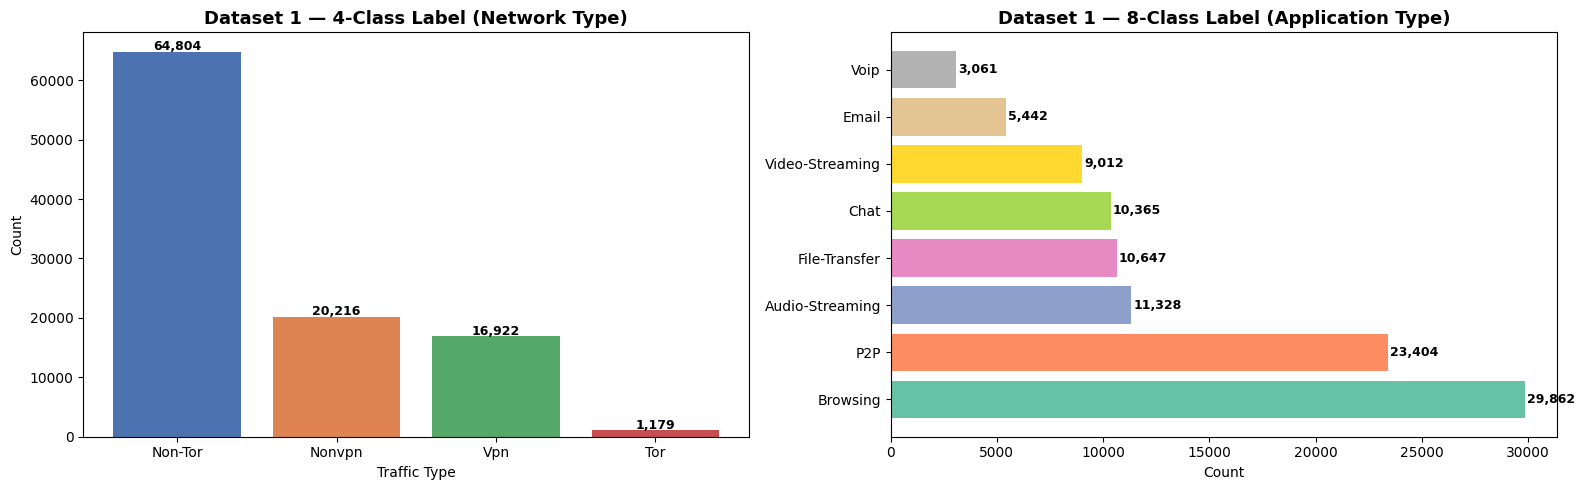


DATASET 1 PREPROCESSING COMPLETE
Total samples  : 103,121
Total features : 62
Task 1 classes : 4 → ['Non-Tor', 'Nonvpn', 'Tor', 'Vpn']
Task 2 classes : 8 → ['Audio-Streaming', 'Browsing', 'Chat', 'Email', 'File-Transfer', 'P2P', 'Video-Streaming', 'Voip']
Train size     : 82,496
Test size      : 20,625

✅ Variables ready for model training!


In [12]:
# ============================================================
# CELL 6 (FIXED) — Preprocessing: Dataset 1 (CIC-Darknet2020)
# ============================================================
# Label   → 4 classes: Non-Tor, Nonvpn, Tor, Vpn
# Label.1 → 8 classes: Audio-Streaming, Browsing, Chat...
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("📂 Loading Dataset 1...")
df1 = pd.read_parquet('/content/datasets/darknet/cicdarknet2020.parquet')
print(f"Original shape: {df1.shape}")

# ── Step 1: Standardize label casing ────────────────────────
df1['Label.1'] = df1['Label.1'].astype(str).str.title()
df1['Label']   = df1['Label'].astype(str).str.title()
print(f"\n✅ Step 1 — Labels standardized")
print(f"   Label (4-class)  : {sorted(df1['Label'].unique())}")
print(f"   Label.1 (8-class): {sorted(df1['Label.1'].unique())}")

# ── Step 2: Drop zero-variance columns ──────────────────────
feature_cols = [c for c in df1.columns if c not in ['Label', 'Label.1']]
zero_var = [c for c in feature_cols if df1[c].nunique() <= 1]
df1.drop(columns=zero_var, inplace=True)
print(f"\n✅ Step 2 — Dropped {len(zero_var)} zero-variance columns")

# ── Step 3: Handle infinite / NaN values ────────────────────
feature_cols = [c for c in df1.columns if c not in ['Label', 'Label.1']]
df1[feature_cols] = df1[feature_cols].replace([np.inf, -np.inf], np.nan)
df1.dropna(inplace=True)
print(f"\n✅ Step 3 — Cleaned. Shape after: {df1.shape}")

# ── Step 4: Encode both label columns ───────────────────────
le_4class = LabelEncoder()   # Non-Tor, Nonvpn, Tor, Vpn
le_8class = LabelEncoder()   # Audio-Streaming, Browsing, Chat...

df1['label_4class'] = le_4class.fit_transform(df1['Label'])
df1['label_8class'] = le_8class.fit_transform(df1['Label.1'])

print(f"\n✅ Step 4 — Labels encoded")
print(f"   4-class mapping: {dict(zip(le_4class.classes_, range(len(le_4class.classes_))))}")
print(f"   8-class mapping: {dict(zip(le_8class.classes_, range(len(le_8class.classes_))))}")

# ── Step 5: Normalize features ──────────────────────────────
feature_cols = [c for c in df1.columns if c not in
                ['Label', 'Label.1', 'label_4class', 'label_8class']]
X = df1[feature_cols].values.astype(np.float32)

scaler1 = MinMaxScaler()
X_scaled = scaler1.fit_transform(X)
print(f"\n✅ Step 5 — Normalized. Feature shape: {X_scaled.shape}")

# ── Step 6: Train/Test split for both tasks ──────────────────
y_4class = df1['label_4class'].values
y_8class = df1['label_8class'].values

# 4-class split
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X_scaled, y_4class, test_size=0.2, random_state=42, stratify=y_4class)

# 8-class split
X_train_8, X_test_8, y_train_8, y_test_8 = train_test_split(
    X_scaled, y_8class, test_size=0.2, random_state=42, stratify=y_8class)

print(f"\n✅ Step 6 — Train/Test split (80/20)")
print(f"   4-class — Train: {X_train_4.shape}, Test: {X_test_4.shape}")
print(f"   8-class — Train: {X_train_8.shape}, Test: {X_test_8.shape}")

# ── Step 7: Reshape for LSTM (samples, timesteps=1, features)
X_train_4_lstm = X_train_4.reshape(X_train_4.shape[0], 1, X_train_4.shape[1])
X_test_4_lstm  = X_test_4.reshape(X_test_4.shape[0],  1, X_test_4.shape[1])
X_train_8_lstm = X_train_8.reshape(X_train_8.shape[0], 1, X_train_8.shape[1])
X_test_8_lstm  = X_test_8.reshape(X_test_8.shape[0],  1, X_test_8.shape[1])

print(f"\n✅ Step 7 — Reshaped for LSTM")
print(f"   4-class LSTM — Train: {X_train_4_lstm.shape}, Test: {X_test_4_lstm.shape}")
print(f"   8-class LSTM — Train: {X_train_8_lstm.shape}, Test: {X_test_8_lstm.shape}")

# ── Step 8: Visualize class distributions ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 4-class
counts_4 = df1['Label'].value_counts()
colors_4  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = axes[0].bar(counts_4.index, counts_4.values, color=colors_4)
axes[0].set_title('Dataset 1 — 4-Class Label (Network Type)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Traffic Type')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts_4.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 200,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=9)

# 8-class
counts_8 = df1['Label.1'].value_counts()
colors_8  = plt.cm.Set2(np.linspace(0, 1, len(counts_8)))
bars2 = axes[1].barh(counts_8.index, counts_8.values, color=colors_8)
axes[1].set_title('Dataset 1 — 8-Class Label (Application Type)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
for bar, val in zip(bars2, counts_8.values):
    axes[1].text(val + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('/content/dataset1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ──────────────────────────────────────────────────
N_FEATURES = X_scaled.shape[1]
print("\n" + "=" * 55)
print("DATASET 1 PREPROCESSING COMPLETE")
print("=" * 55)
print(f"Total samples  : {X_scaled.shape[0]:,}")
print(f"Total features : {N_FEATURES}")
print(f"Task 1 classes : {len(le_4class.classes_)} → {list(le_4class.classes_)}")
print(f"Task 2 classes : {len(le_8class.classes_)} → {list(le_8class.classes_)}")
print(f"Train size     : {X_train_4.shape[0]:,}")
print(f"Test size      : {X_test_4.shape[0]:,}")
print("\n✅ Variables ready for model training!")

In [13]:
# ============================================================
# CELL — Download Dataset 2: CICIDS2017 (Fixed)
# ============================================================

import os
import pandas as pd
import numpy as np

os.makedirs('/content/datasets/cicids', exist_ok=True)

# Try the correct dataset slug
print("⬇️  Downloading CICIDS2017 dataset (fixed link)...")
ret = os.system('kaggle datasets download -d chethuhn/network-intrusion-dataset '
                '-p /content/datasets/cicids --unzip')

print("\n📁 All files found:")
all_files = []
for root, dirs, files in os.walk('/content/datasets/cicids'):
    for f in files:
        fp = os.path.join(root, f)
        size = os.path.getsize(fp) / (1024*1024)
        print(f"   {f}  ({size:.1f} MB)")
        if f.endswith('.csv'):
            all_files.append(fp)

print(f"\nTotal CSV files: {len(all_files)}")

# ── Load and combine ─────────────────────────────────────────
print("\n📊 Loading CSV files...")
dfs = []
for fp in all_files:
    try:
        tmp = pd.read_csv(fp, encoding='utf-8', low_memory=False)
        # Strip whitespace from column names (common issue in this dataset)
        tmp.columns = tmp.columns.str.strip()
        dfs.append(tmp)
        print(f"   ✅ {os.path.basename(fp)} → {tmp.shape}")
    except Exception as e:
        print(f"   ⚠️  {os.path.basename(fp)}: {e}")

if len(dfs) == 0:
    print("\n❌ No CSV files loaded. Paste the full file list above so we can debug.")
else:
    df2_raw = pd.concat(dfs, ignore_index=True)
    df2_raw.columns = df2_raw.columns.str.strip()
    print(f"\n✅ Combined shape: {df2_raw.shape}")

    # Find label column
    label_col = [c for c in df2_raw.columns if 'label' in c.lower()][0]
    print(f"Label column: '{label_col}'")
    print(f"\nClass distribution:")
    print(df2_raw[label_col].value_counts())
    print(f"\nMissing values: {df2_raw.isnull().sum().sum()}")
    print(f"Columns (first 10): {list(df2_raw.columns[:10])}")

⬇️  Downloading CICIDS2017 dataset (fixed link)...

📁 All files found:
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (73.6 MB)
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (73.3 MB)
   Tuesday-WorkingHours.pcap_ISCX.csv  (128.8 MB)
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (49.6 MB)
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (79.3 MB)
   Wednesday-workingHours.pcap_ISCX.csv  (214.7 MB)
   Monday-WorkingHours.pcap_ISCX.csv  (168.7 MB)
   Friday-WorkingHours-Morning.pcap_ISCX.csv  (55.6 MB)

Total CSV files: 8

📊 Loading CSV files...
   ✅ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → (225745, 79)
   ✅ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → (286467, 79)
   ✅ Tuesday-WorkingHours.pcap_ISCX.csv → (445909, 79)
   ✅ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → (170366, 79)
   ✅ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → (288602, 79)
   ✅ Wednesday-workingHours.pcap_ISCX.csv → (692703, 

📂 Using already-loaded df2_raw...
Original shape: (2830743, 79)

✅ Step 1 — Dropped NaN rows. Shape: (2829385, 79)
✅ Step 2 — Replaced inf values. Shape: (2827876, 79)
✅ Step 3 — Dropped 8 zero-variance columns

✅ Step 4 — Label names cleaned
   Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack  Brute Force', 'Web Attack  Sql Injection', 'Web Attack  XSS']

✅ Step 5 — Balancing classes (cap at 50,000 each)...
   Shape after balancing: (239535, 71)
   Class distribution after balancing:
Label
BENIGN                     50000
DDoS                       50000
DoS Hulk                   50000
PortScan                   50000
DoS GoldenEye              10293
FTP-Patator                 7935
SSH-Patator                 5897
DoS slowloris               5796
DoS Slowhttptest            5499
Bot                         1956
Web Attack  Brute Force     1507
Web A

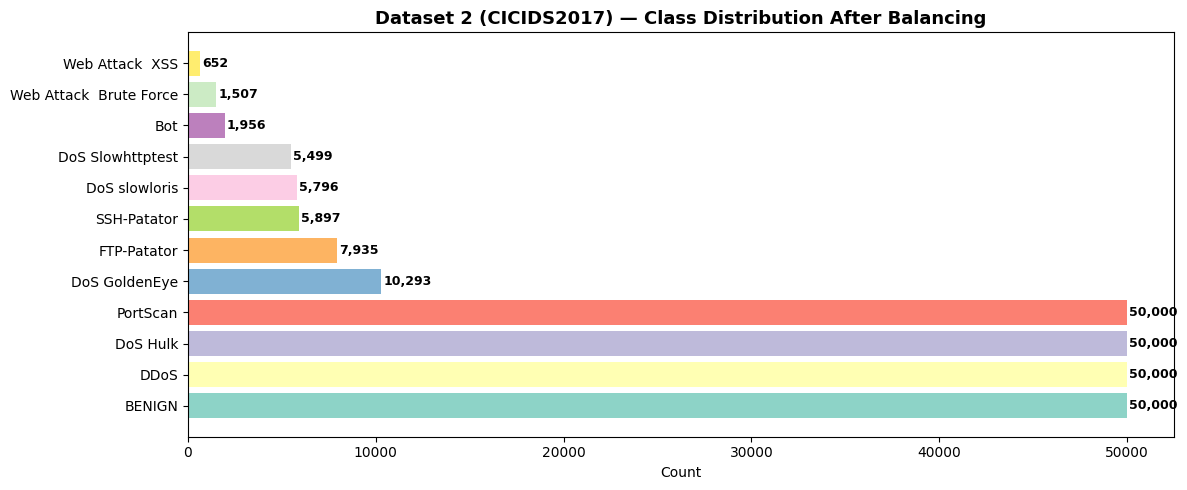


DATASET 2 PREPROCESSING COMPLETE
Total samples  : 239,535
Total features : 70
Classes        : 12 → ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack  Brute Force', 'Web Attack  XSS']
Train size     : 191,628
Test size      : 47,907

✅ Dataset 2 ready for model training!


In [14]:
# ============================================================
# CELL — Preprocessing: Dataset 2 (CICIDS2017)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("📂 Using already-loaded df2_raw...")
df2 = df2_raw.copy()
print(f"Original shape: {df2.shape}")

# ── Step 1: Strip column name whitespace ─────────────────────
df2.columns = df2.columns.str.strip()

# ── Step 2: Drop rows with missing values ────────────────────
df2.dropna(inplace=True)
print(f"\n✅ Step 1 — Dropped NaN rows. Shape: {df2.shape}")

# ── Step 3: Replace infinite values ──────────────────────────
label_col = 'Label'
feature_cols = [c for c in df2.columns if c != label_col]
df2[feature_cols] = df2[feature_cols].replace([np.inf, -np.inf], np.nan)
df2.dropna(inplace=True)
print(f"✅ Step 2 — Replaced inf values. Shape: {df2.shape}")

# ── Step 4: Drop zero-variance columns ───────────────────────
zero_var = [c for c in feature_cols if df2[c].nunique() <= 1]
df2.drop(columns=zero_var, inplace=True)
feature_cols = [c for c in df2.columns if c != label_col]
print(f"✅ Step 3 — Dropped {len(zero_var)} zero-variance columns")

# ── Step 5: Fix encoding issues in label names ───────────────
df2[label_col] = df2[label_col].str.strip()
df2[label_col] = df2[label_col].str.replace('â€\x93', '-', regex=False)
df2[label_col] = df2[label_col].str.replace('\ufffd', '', regex=False)
df2[label_col] = df2[label_col].str.strip()
print(f"\n✅ Step 4 — Label names cleaned")
print(f"   Classes: {sorted(df2[label_col].unique())}")

# ── Step 6: Handle class imbalance via undersampling ─────────
# BENIGN has 2.2M samples which would dominate training
# Cap each class at 50,000 samples max
print(f"\n✅ Step 5 — Balancing classes (cap at 50,000 each)...")
MAX_PER_CLASS = 50000

# Also remove very rare classes (less than 100 samples) — too few to learn
class_counts = df2[label_col].value_counts()
valid_classes = class_counts[class_counts >= 100].index.tolist()
df2 = df2[df2[label_col].isin(valid_classes)]

balanced_dfs = []
for cls in valid_classes:
    cls_df = df2[df2[label_col] == cls]
    if len(cls_df) > MAX_PER_CLASS:
        cls_df = cls_df.sample(n=MAX_PER_CLASS, random_state=42)
    balanced_dfs.append(cls_df)

df2 = pd.concat(balanced_dfs, ignore_index=True).sample(frac=1, random_state=42)
print(f"   Shape after balancing: {df2.shape}")
print(f"   Class distribution after balancing:")
print(df2[label_col].value_counts())

# ── Step 7: Encode labels ────────────────────────────────────
le_cicids = LabelEncoder()
df2['label_encoded'] = le_cicids.fit_transform(df2[label_col])
n_classes_cicids = len(le_cicids.classes_)

print(f"\n✅ Step 6 — Labels encoded")
print(f"   {n_classes_cicids} classes: {list(le_cicids.classes_)}")

# ── Step 8: Normalize features ───────────────────────────────
feature_cols = [c for c in df2.columns if c not in [label_col, 'label_encoded']]
X2 = df2[feature_cols].values.astype(np.float32)
scaler2 = MinMaxScaler()
X2_scaled = scaler2.fit_transform(X2)
y2 = df2['label_encoded'].values

print(f"\n✅ Step 7 — Normalized. Feature shape: {X2_scaled.shape}")

# ── Step 9: Train/test split & reshape ───────────────────────
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42, stratify=y2)

X2_train_lstm = X2_train.reshape(X2_train.shape[0], 1, X2_train.shape[1])
X2_test_lstm  = X2_test.reshape(X2_test.shape[0],  1, X2_test.shape[1])

print(f"\n✅ Step 8 — Split & reshaped for LSTM")
print(f"   Train: {X2_train_lstm.shape}, Test: {X2_test_lstm.shape}")

# ── Step 10: Visualize ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
counts = df2[label_col].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(counts)))
bars = ax.barh(counts.index, counts.values, color=colors)
ax.set_title('Dataset 2 (CICIDS2017) — Class Distribution After Balancing',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
for bar, val in zip(bars, counts.values):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/dataset2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ──────────────────────────────────────────────────
N_FEATURES_D2 = X2_scaled.shape[1]
print("\n" + "=" * 55)
print("DATASET 2 PREPROCESSING COMPLETE")
print("=" * 55)
print(f"Total samples  : {X2_scaled.shape[0]:,}")
print(f"Total features : {N_FEATURES_D2}")
print(f"Classes        : {n_classes_cicids} → {list(le_cicids.classes_)}")
print(f"Train size     : {X2_train.shape[0]:,}")
print(f"Test size      : {X2_test.shape[0]:,}")
print("\n✅ Dataset 2 ready for model training!")

In [15]:
# ============================================================
# CELL 7 (FIXED) — Build All 3 Models (Multi-class)
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Conv1D,
    LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, BatchNormalization
)
import numpy as np

print("TensorFlow:", tf.__version__)

N_FEATURES   = X_train_4_lstm.shape[2]   # 62 features
N_CLASSES_4  = len(le_4class.classes_)   # 4 classes
N_CLASSES_8  = len(le_8class.classes_)   # 8 classes

print(f"Features   : {N_FEATURES}")
print(f"4-class    : {N_CLASSES_4} → {list(le_4class.classes_)}")
print(f"8-class    : {N_CLASSES_8} → {list(le_8class.classes_)}")

# ── MODEL BUILDER FUNCTIONS ───────────────────────────────────
# Each function accepts n_classes so we reuse for both tasks

def build_lstm(n_features, n_classes, name_suffix=''):
    """Simple LSTM baseline"""
    inputs = Input(shape=(1, n_features), name='input')
    x = LSTM(128, return_sequences=False, name='lstm')(inputs)
    x = Dropout(0.3, name='drop1')(x)
    x = Dense(64, activation='relu', name='dense1')(x)
    x = Dropout(0.2, name='drop2')(x)
    outputs = Dense(n_classes, activation='softmax', name='output')(x)
    model = Model(inputs, outputs, name=f'LSTM_{name_suffix}')
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_cnn_lstm(n_features, n_classes, name_suffix=''):
    """CNN-LSTM hybrid (base paper architecture)"""
    inputs = Input(shape=(1, n_features), name='input')
    # CNN block
    x = Conv1D(64,  kernel_size=1, activation='relu', padding='same', name='conv1')(inputs)
    x = BatchNormalization(name='bn1')(x)
    x = Conv1D(128, kernel_size=1, activation='relu', padding='same', name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Dropout(0.2, name='drop1')(x)
    # LSTM block
    x = LSTM(128, return_sequences=False, name='lstm')(x)
    x = Dropout(0.3, name='drop2')(x)
    # Head
    x = Dense(64, activation='relu', name='dense1')(x)
    x = Dropout(0.2, name='drop3')(x)
    outputs = Dense(n_classes, activation='softmax', name='output')(x)
    model = Model(inputs, outputs, name=f'CNN_LSTM_{name_suffix}')
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_transformer_lstm(n_features, n_classes, name_suffix=''):
    """Transformer-Enhanced LSTM (proposed model)"""
    inputs = Input(shape=(1, n_features), name='input')

    # LSTM: learn sequential traffic behaviour
    x = LSTM(128, return_sequences=True, name='lstm')(inputs)
    x = LayerNormalization(name='ln1')(x)

    # Multi-Head Self-Attention: focus on important features
    attn = MultiHeadAttention(
        num_heads=4, key_dim=32, dropout=0.1,
        name='attention'
    )(x, x)

    # Residual connection + LayerNorm
    x = tf.keras.layers.Add(name='add1')([x, attn])
    x = LayerNormalization(name='ln2')(x)

    # Feed-Forward Network (Transformer FFN block)
    ffn = Dense(256, activation='relu', name='ffn1')(x)
    ffn = Dropout(0.1, name='ffn_drop')(ffn)
    ffn = Dense(128, name='ffn2')(ffn)

    # Second residual + LayerNorm
    x = tf.keras.layers.Add(name='add2')([x, ffn])
    x = LayerNormalization(name='ln3')(x)

    # Pooling & classification head
    x = GlobalAveragePooling1D(name='gap')(x)
    x = Dense(64, activation='relu', name='dense1')(x)
    x = Dropout(0.3, name='drop1')(x)
    outputs = Dense(n_classes, activation='softmax', name='output')(x)

    model = Model(inputs, outputs, name=f'TransformerLSTM_{name_suffix}')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Build models for TASK 1: 4-class ────────────────────────
print("\n" + "="*55)
print("Building models for Task 1 (4-class: Tor/VPN types)")
print("="*55)
m1_4 = build_lstm(N_FEATURES, N_CLASSES_4, '4class')
m2_4 = build_cnn_lstm(N_FEATURES, N_CLASSES_4, '4class')
m3_4 = build_transformer_lstm(N_FEATURES, N_CLASSES_4, '4class')

for m, label in [(m1_4,'LSTM'), (m2_4,'CNN-LSTM'), (m3_4,'Transformer-LSTM')]:
    print(f"\n{label}: {m.count_params():,} parameters")
    m.summary()

# ── Build models for TASK 2: 8-class ────────────────────────
print("\n" + "="*55)
print("Building models for Task 2 (8-class: Application type)")
print("="*55)
m1_8 = build_lstm(N_FEATURES, N_CLASSES_8, '8class')
m2_8 = build_cnn_lstm(N_FEATURES, N_CLASSES_8, '8class')
m3_8 = build_transformer_lstm(N_FEATURES, N_CLASSES_8, '8class')

for m, label in [(m1_8,'LSTM'), (m2_8,'CNN-LSTM'), (m3_8,'Transformer-LSTM')]:
    print(f"\n{label}: {m.count_params():,} parameters")

print("\n✅ All 6 models built successfully!")
print("   3 models × 2 tasks = 6 total")

TensorFlow: 2.20.0
Features   : 62
4-class    : 4 → ['Non-Tor', 'Nonvpn', 'Tor', 'Vpn']
8-class    : 8 → ['Audio-Streaming', 'Browsing', 'Chat', 'Email', 'File-Transfer', 'P2P', 'Video-Streaming', 'Voip']

Building models for Task 1 (4-class: Tor/VPN types)

LSTM: 106,308 parameters


Model: "LSTM_4class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1, 62)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        97,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,308 (415.27 KB)

 Trainable params: 106,308 (415.27 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 1, 62)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 1, 128)    │     97,792 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln1                 │ (None, 1, 128)    │        256 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 1, 128)    │     66,048 │ ln1[0][0],        │
│ (MultiHeadAttentio… │                   │            │ ln1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add1 (Add)          │ (None, 1, 128)    │          0 │ ln1[0][0],        │
│                     │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln2                 │ (None, 1, 128)    │        256 │ add1[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn1 (Dense)        │ (None, 1, 256)    │     33,024 │ ln2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_drop (Dropout)  │ (None, 1, 256)    │          0 │ ffn1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn2 (Dense)        │ (None, 1, 128)    │     32,896 │ ffn_drop[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add2 (Add)          │ (None, 1, 128)    │          0 │ ln2[0][0],        │
│                     │                   │            │ ffn2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln3                 │ (None, 1, 128)    │        256 │ add2[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ ln3[0][0]         │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 64)        │      8,256 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 64)        │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        260 │ drop1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 239,044 (933.77 KB)

 Trainable params: 239,044 (933.77 KB)

 Non-trainable params: 0 (0.00 B)


Building models for Task 2 (8-class: Application type)

LSTM: 106,568 parameters

CNN-LSTM: 153,480 parameters

Transformer-LSTM: 239,304 parameters

✅ All 6 models built successfully!
   3 models × 2 tasks = 6 total


🔄 Rebuilding all models with fresh weights...

Dataset 2 — Features: 70, Classes: 12
✅ All 9 models ready

TASK 1 — Dataset 1 — 4-Class (Tor/VPN Network Type)

▶  Training LSTM [D1_4class]...
Epoch 1/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7359 - loss: 0.7457 - val_accuracy: 0.8201 - val_loss: 0.5055 - learning_rate: 0.0010
Epoch 2/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8356 - loss: 0.4548 - val_accuracy: 0.8568 - val_loss: 0.3998 - learning_rate: 0.0010
Epoch 3/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8558 - loss: 0.3951 - val_accuracy: 0.8679 - val_loss: 0.3633 - learning_rate: 0.0010
Epoch 4/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8640 - loss: 0.3700 - val_accuracy: 0.8679 - val_loss: 0.3471 - learning_rate: 0.0010
Epoch 5/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8677 - loss: 0.3557 - val_accuracy: 0.8730 - val_loss: 0.3378 - learning_rate: 0.0010
Epoch 6/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/s

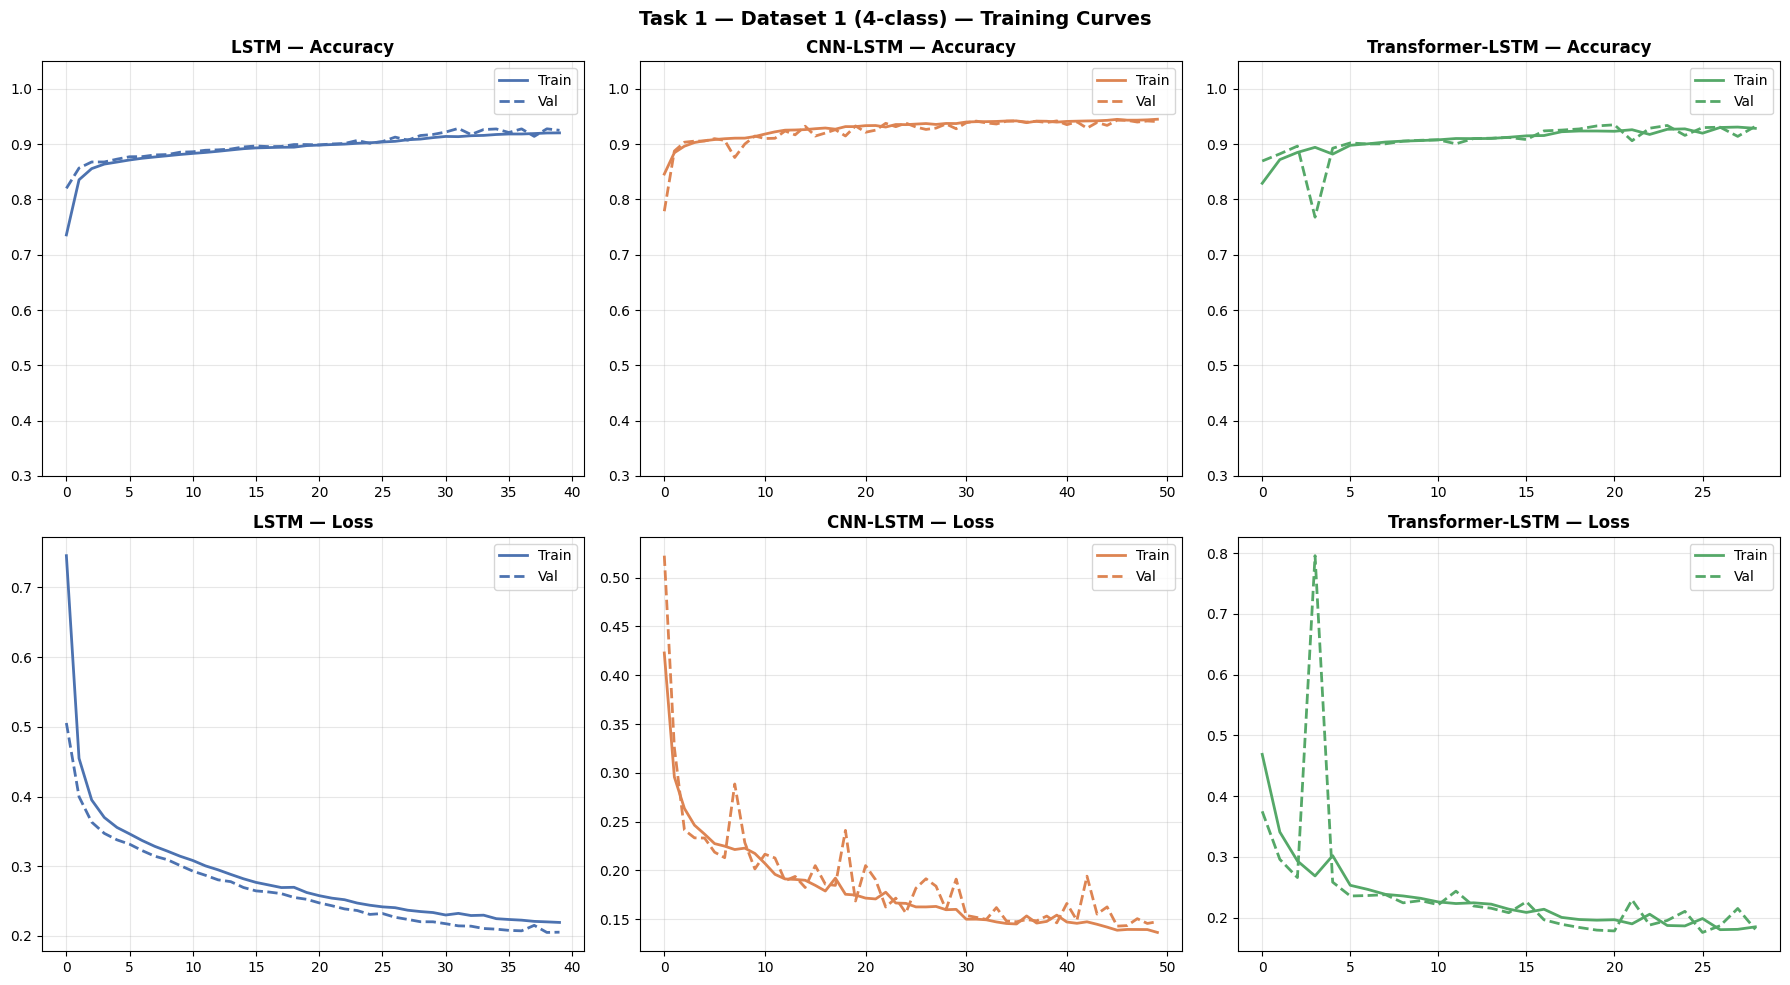

   Saved: /content/D1_4class_curves.png


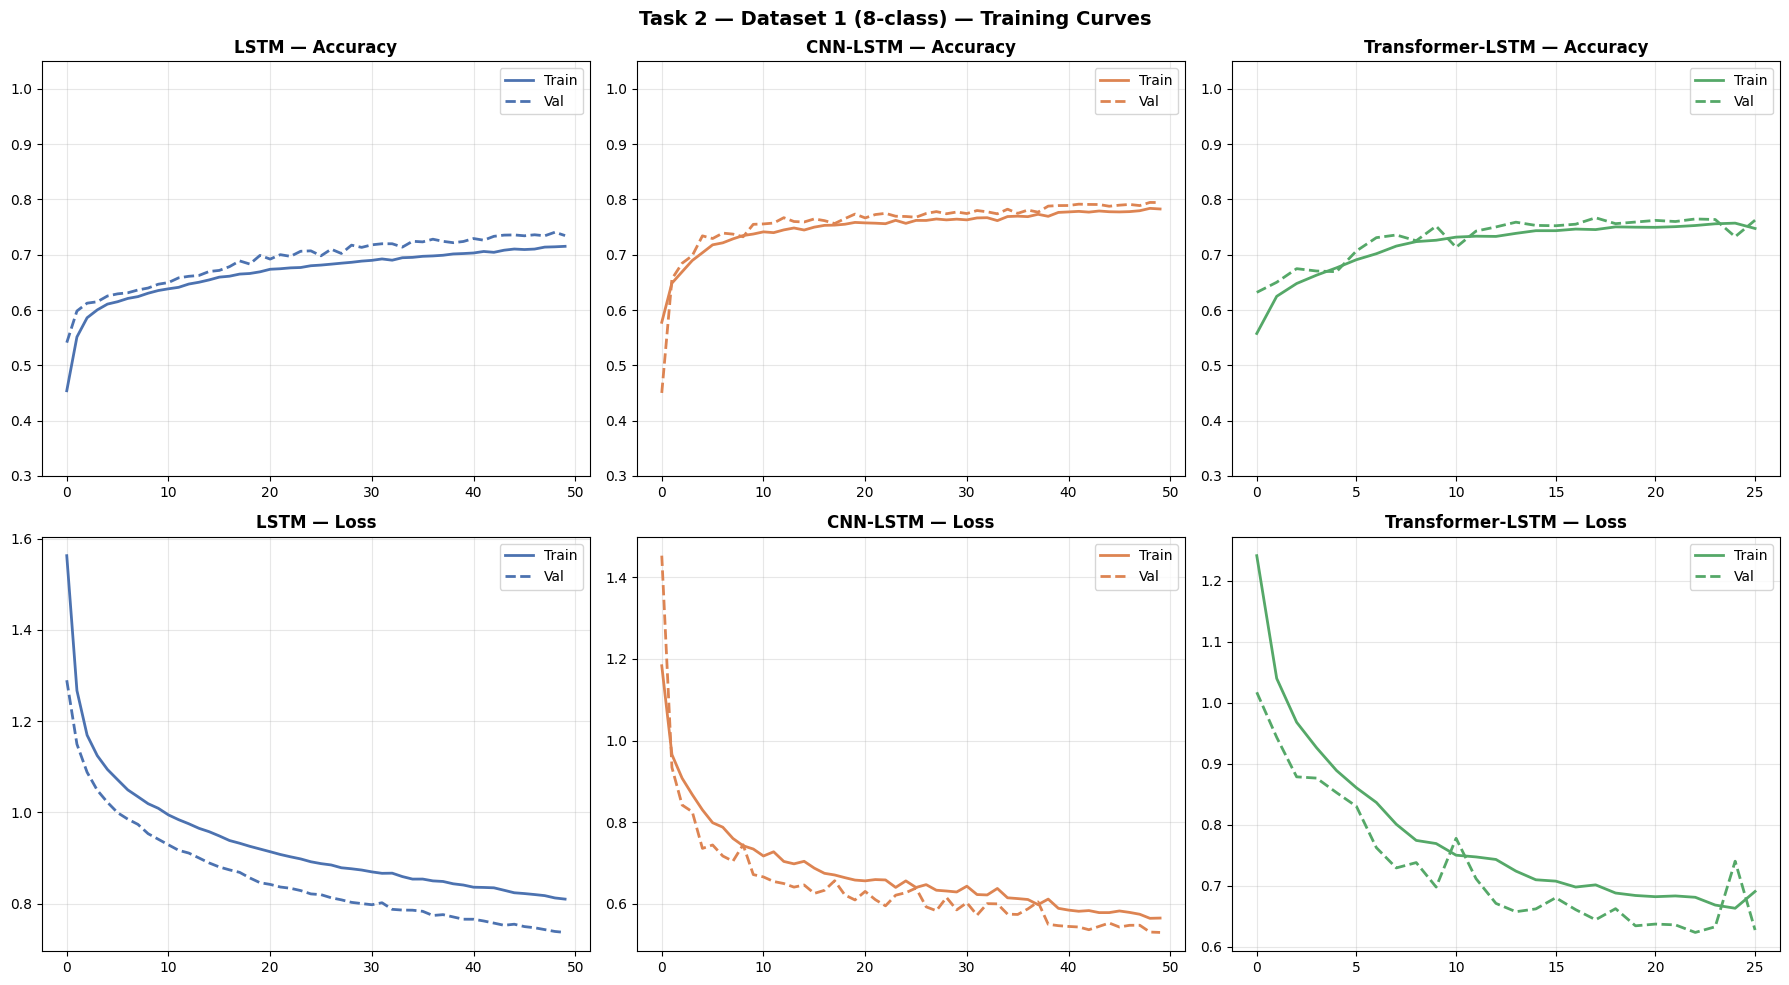

   Saved: /content/D1_8class_curves.png


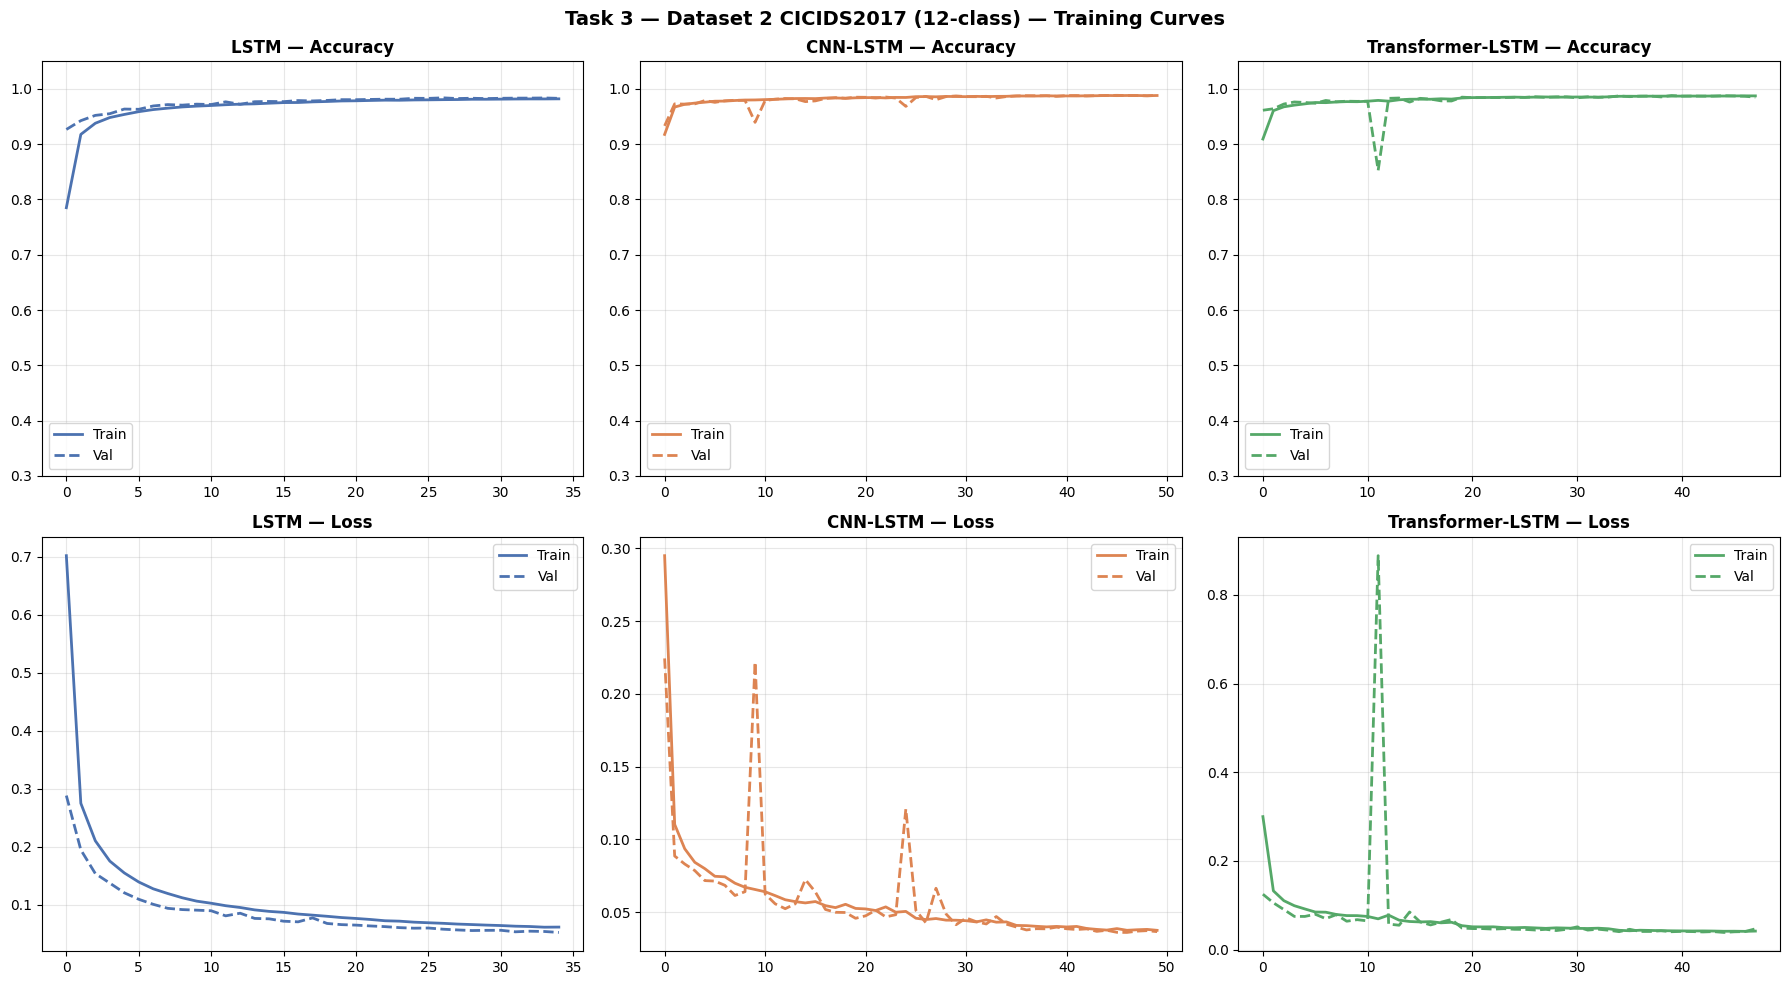

   Saved: /content/D2_cicids_curves.png

✅ All 9 models trained!


In [17]:
# ============================================================
# CELL 8 (IMPROVED) — Retrain With Better Config
# ============================================================
# Fix: Increase patience so models don't stop too early
# Fix: Add Dataset 2 (CICIDS2017) training
# ============================================================

import time
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

EPOCHS     = 50
BATCH_SIZE = 256

# Better callbacks — more patience this time
def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=8,              # was 5 — give models more time
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,              # was 3 — don't reduce LR too fast
            min_lr=1e-6,
            verbose=1
        )
    ]

# ── Rebuild all models fresh (clean weights) ─────────────────
print("🔄 Rebuilding all models with fresh weights...\n")

# Dataset 1 models
m1_4 = build_lstm(N_FEATURES, N_CLASSES_4, '4class')
m2_4 = build_cnn_lstm(N_FEATURES, N_CLASSES_4, '4class')
m3_4 = build_transformer_lstm(N_FEATURES, N_CLASSES_4, '4class')
m1_8 = build_lstm(N_FEATURES, N_CLASSES_8, '8class')
m2_8 = build_cnn_lstm(N_FEATURES, N_CLASSES_8, '8class')
m3_8 = build_transformer_lstm(N_FEATURES, N_CLASSES_8, '8class')

# Dataset 2 models
N_FEATURES_D2   = X2_train_lstm.shape[2]
N_CLASSES_CICIDS = len(le_cicids.classes_)
m1_d2 = build_lstm(N_FEATURES_D2, N_CLASSES_CICIDS, 'cicids')
m2_d2 = build_cnn_lstm(N_FEATURES_D2, N_CLASSES_CICIDS, 'cicids')
m3_d2 = build_transformer_lstm(N_FEATURES_D2, N_CLASSES_CICIDS, 'cicids')

print(f"Dataset 2 — Features: {N_FEATURES_D2}, Classes: {N_CLASSES_CICIDS}")
print("✅ All 9 models ready\n")

histories = {}
train_times = {}

# ── Helper to train one model ─────────────────────────────────
def train_model(model, X_train, y_train, name, tag):
    key = f"{tag}_{name}"
    print(f"\n▶  Training {name} [{tag}]...")
    t0 = time.time()
    hist = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=get_callbacks(),
        verbose=1
    )
    elapsed = time.time() - t0
    best_val = max(hist.history['val_accuracy'])
    print(f"   ✅ Done in {elapsed:.1f}s — Best val accuracy: {best_val*100:.2f}%")
    histories[key]    = hist
    train_times[key]  = elapsed
    return hist

# ── TASK 1: Dataset 1 — 4-class ──────────────────────────────
print("=" * 55)
print("TASK 1 — Dataset 1 — 4-Class (Tor/VPN Network Type)")
print("=" * 55)
train_model(m1_4, X_train_4_lstm, y_train_4, 'LSTM',              'D1_4class')
train_model(m2_4, X_train_4_lstm, y_train_4, 'CNN-LSTM',          'D1_4class')
train_model(m3_4, X_train_4_lstm, y_train_4, 'Transformer-LSTM',  'D1_4class')

# ── TASK 2: Dataset 1 — 8-class ──────────────────────────────
print("\n" + "=" * 55)
print("TASK 2 — Dataset 1 — 8-Class (Application Type)")
print("=" * 55)
train_model(m1_8, X_train_8_lstm, y_train_8, 'LSTM',              'D1_8class')
train_model(m2_8, X_train_8_lstm, y_train_8, 'CNN-LSTM',          'D1_8class')
train_model(m3_8, X_train_8_lstm, y_train_8, 'Transformer-LSTM',  'D1_8class')

# ── TASK 3: Dataset 2 — CICIDS2017 ───────────────────────────
print("\n" + "=" * 55)
print("TASK 3 — Dataset 2 — CICIDS2017 (12-Class Attack Types)")
print("=" * 55)
train_model(m1_d2, X2_train_lstm, y2_train, 'LSTM',             'D2_cicids')
train_model(m2_d2, X2_train_lstm, y2_train, 'CNN-LSTM',         'D2_cicids')
train_model(m3_d2, X2_train_lstm, y2_train, 'Transformer-LSTM', 'D2_cicids')

# ── Plot all training curves ──────────────────────────────────
def plot_curves(tag, label, histories):
    keys = [f"{tag}_LSTM", f"{tag}_CNN-LSTM", f"{tag}_Transformer-LSTM"]
    names = ['LSTM', 'CNN-LSTM', 'Transformer-LSTM']
    colors = ['#4C72B0', '#DD8452', '#55A868']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for col, (key, name, color) in enumerate(zip(keys, names, colors)):
        if key not in histories:
            continue
        hist = histories[key]
        axes[0,col].plot(hist.history['accuracy'],     color=color, lw=2, label='Train')
        axes[0,col].plot(hist.history['val_accuracy'], color=color, lw=2, ls='--', label='Val')
        axes[0,col].set_title(f'{name} — Accuracy', fontweight='bold')
        axes[0,col].set_ylim([0.3, 1.05])
        axes[0,col].legend(); axes[0,col].grid(alpha=0.3)

        axes[1,col].plot(hist.history['loss'],     color=color, lw=2, label='Train')
        axes[1,col].plot(hist.history['val_loss'], color=color, lw=2, ls='--', label='Val')
        axes[1,col].set_title(f'{name} — Loss', fontweight='bold')
        axes[1,col].legend(); axes[1,col].grid(alpha=0.3)

    plt.suptitle(f'{label} — Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'/content/{tag}_curves.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   Saved: {fname}")

plot_curves('D1_4class', 'Task 1 — Dataset 1 (4-class)', histories)
plot_curves('D1_8class', 'Task 2 — Dataset 1 (8-class)', histories)
plot_curves('D2_cicids', 'Task 3 — Dataset 2 CICIDS2017 (12-class)', histories)

print("\n✅ All 9 models trained!")


  Task 1 — Dataset 1: 4-Class (Tor/VPN)

  ── LSTM ──
  Accuracy : 92.83%  Precision: 92.78%  Recall: 92.83%  F1: 92.77%
              precision    recall  f1-score   support

     Non-Tor       0.98      0.99      0.99     12961
      Nonvpn       0.85      0.81      0.83      4043
         Tor       0.98      0.75      0.85       236
         Vpn       0.81      0.83      0.82      3385

    accuracy                           0.93     20625
   macro avg       0.91      0.85      0.87     20625
weighted avg       0.93      0.93      0.93     20625


  ── CNN-LSTM ──
  Accuracy : 94.31%  Precision: 94.42%  Recall: 94.31%  F1: 94.32%
              precision    recall  f1-score   support

     Non-Tor       0.99      0.99      0.99     12961
      Nonvpn       0.89      0.83      0.86      4043
         Tor       0.98      0.80      0.88       236
         Vpn       0.82      0.89      0.85      3385

    accuracy                           0.94     20625
   macro avg       0.92      0.8

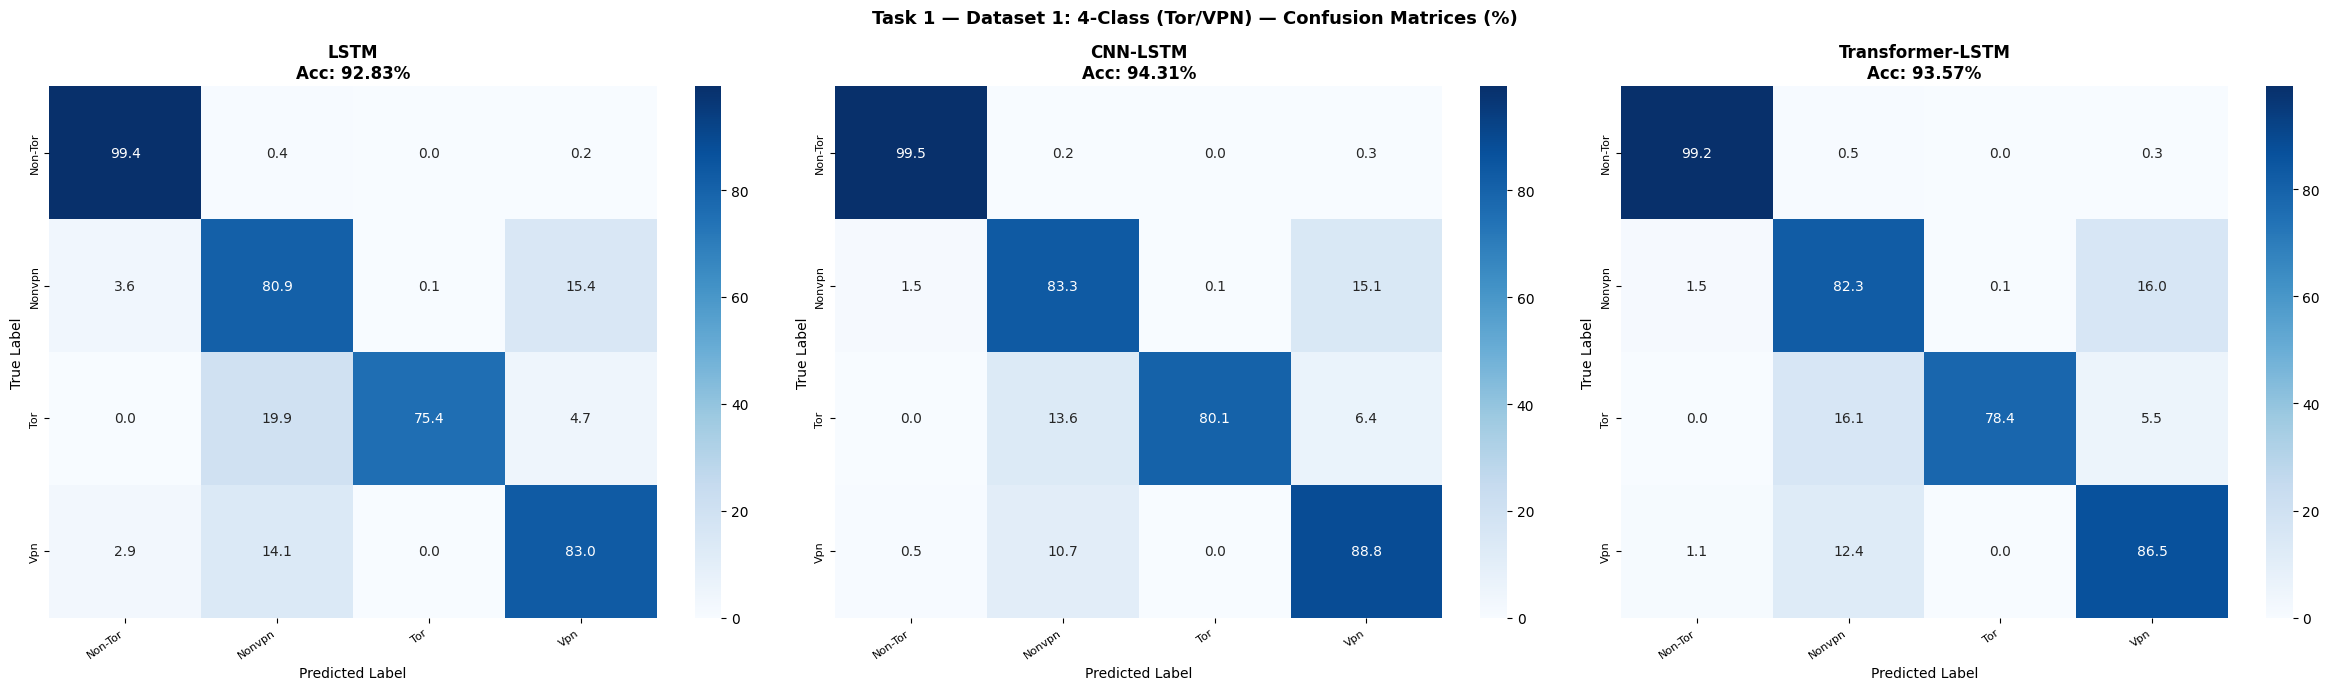

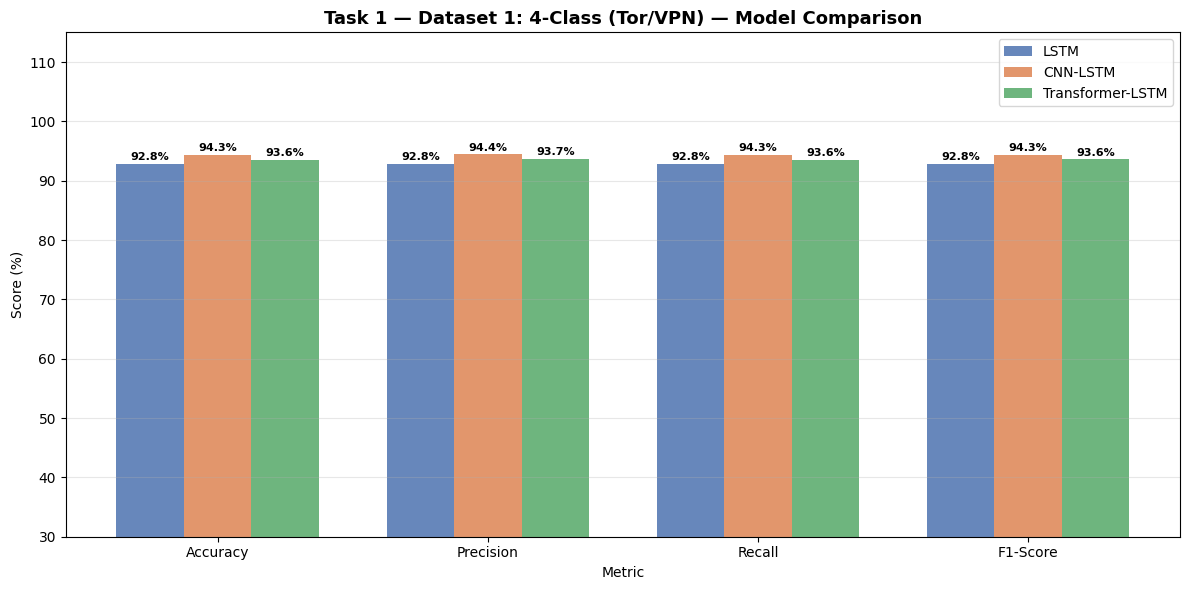


  Task 2 — Dataset 1: 8-Class (Application Type)

  ── LSTM ──
  Accuracy : 74.24%  Precision: 74.38%  Recall: 74.24%  F1: 72.11%
                 precision    recall  f1-score   support

Audio-Streaming       0.64      0.72      0.68      2266
       Browsing       0.78      0.94      0.86      5973
           Chat       0.54      0.78      0.64      2073
          Email       0.62      0.17      0.27      1088
  File-Transfer       0.76      0.51      0.61      2130
            P2P       0.92      0.93      0.92      4681
Video-Streaming       0.54      0.41      0.47      1802
           Voip       0.85      0.14      0.25       612

       accuracy                           0.74     20625
      macro avg       0.71      0.57      0.59     20625
   weighted avg       0.74      0.74      0.72     20625


  ── CNN-LSTM ──
  Accuracy : 79.04%  Precision: 79.33%  Recall: 79.04%  F1: 77.98%
                 precision    recall  f1-score   support

Audio-Streaming       0.78      0.70   

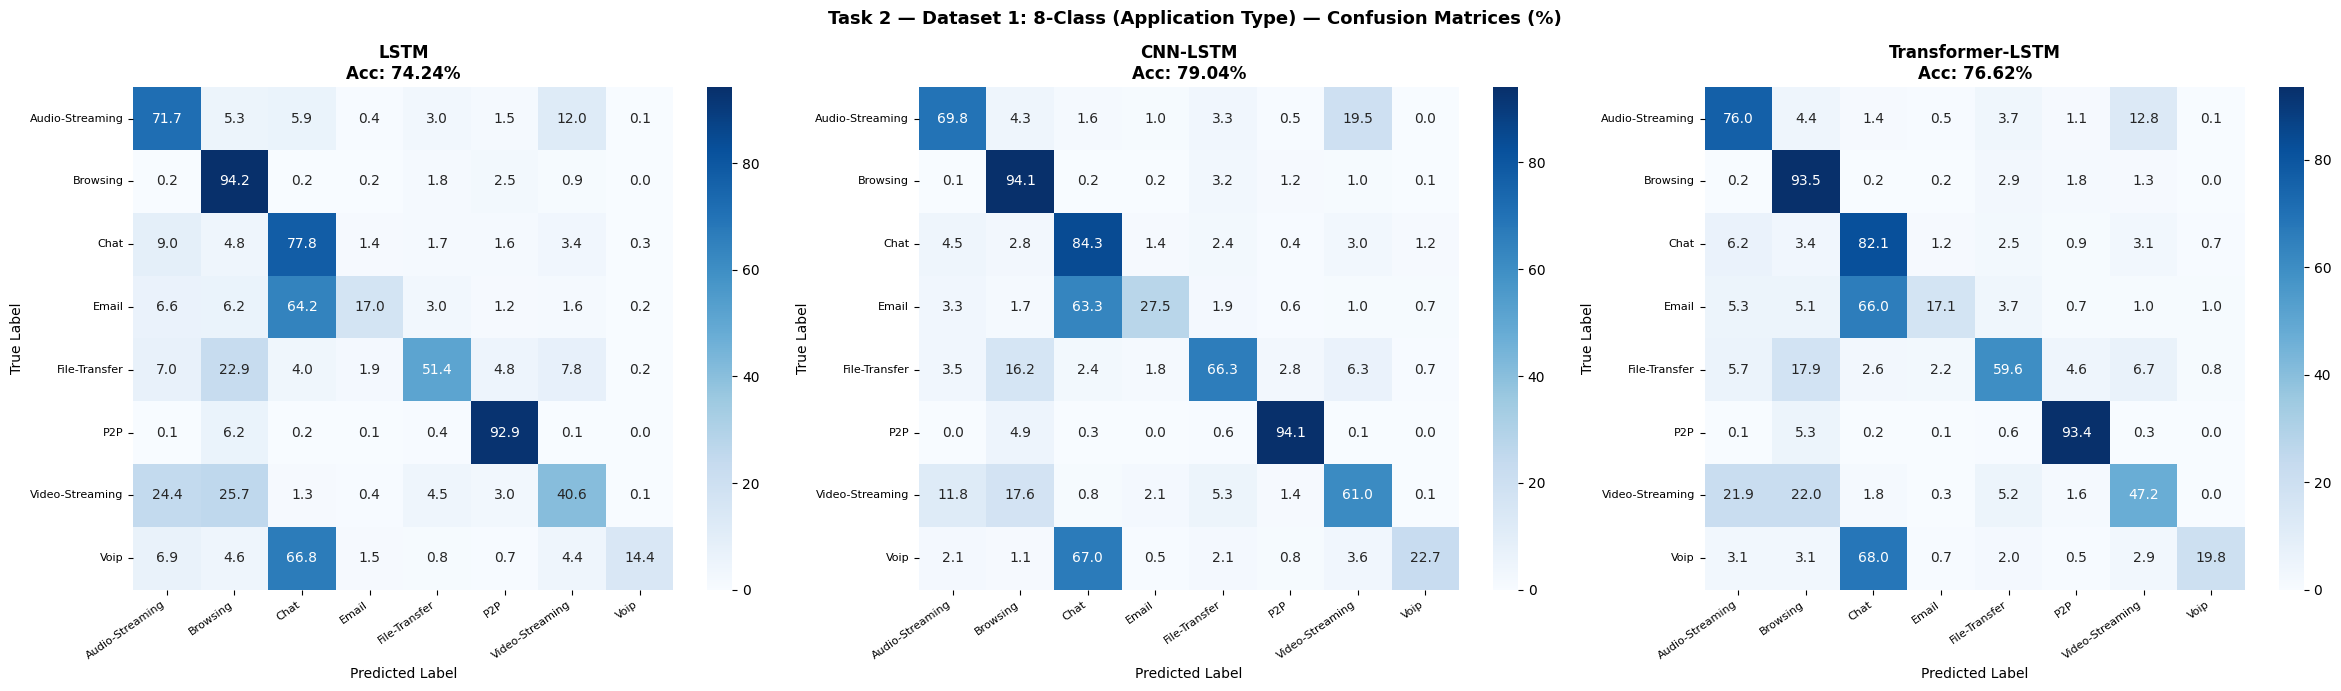

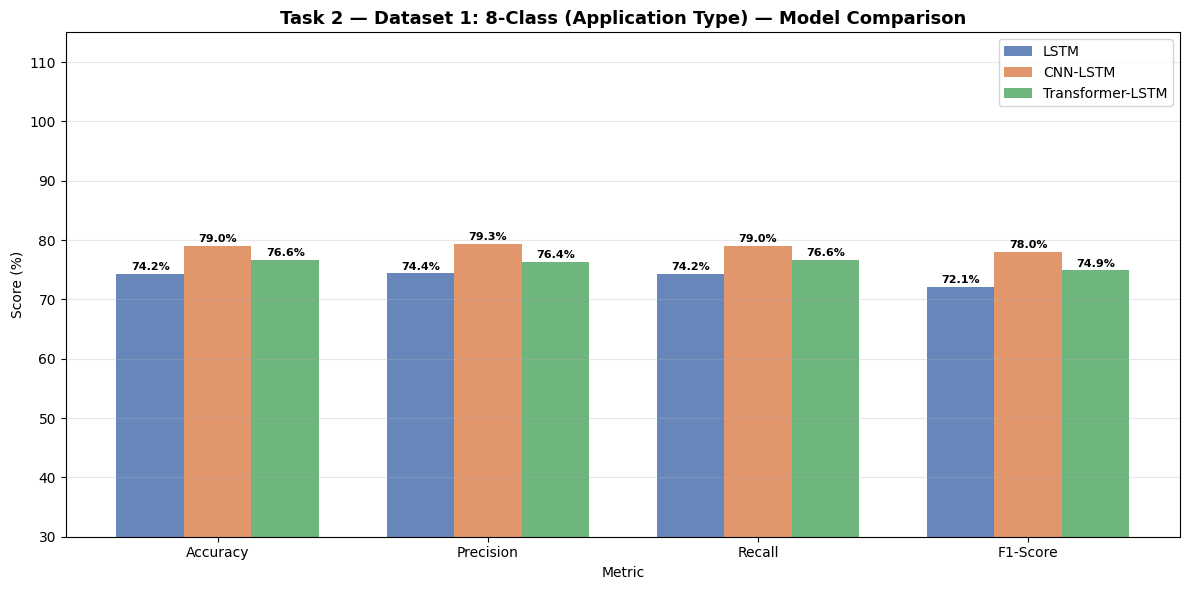


  Task 3 — Dataset 2: CICIDS2017 (12-Class Attacks)

  ── LSTM ──
  Accuracy : 98.48%  Precision: 98.59%  Recall: 98.48%  F1: 98.37%
                         precision    recall  f1-score   support

                 BENIGN       0.99      0.96      0.97     10000
                    Bot       0.97      0.71      0.82       391
                   DDoS       1.00      1.00      1.00     10000
          DoS GoldenEye       0.99      1.00      0.99      2059
               DoS Hulk       0.99      1.00      0.99     10000
       DoS Slowhttptest       0.98      0.99      0.99      1100
          DoS slowloris       0.98      0.99      0.98      1159
            FTP-Patator       1.00      0.99      0.99      1587
               PortScan       0.98      1.00      0.99     10000
            SSH-Patator       0.96      0.99      0.98      1179
Web Attack  Brute Force       0.61      0.90      0.73       302
        Web Attack  XSS       1.00      0.02      0.05       130

               accu

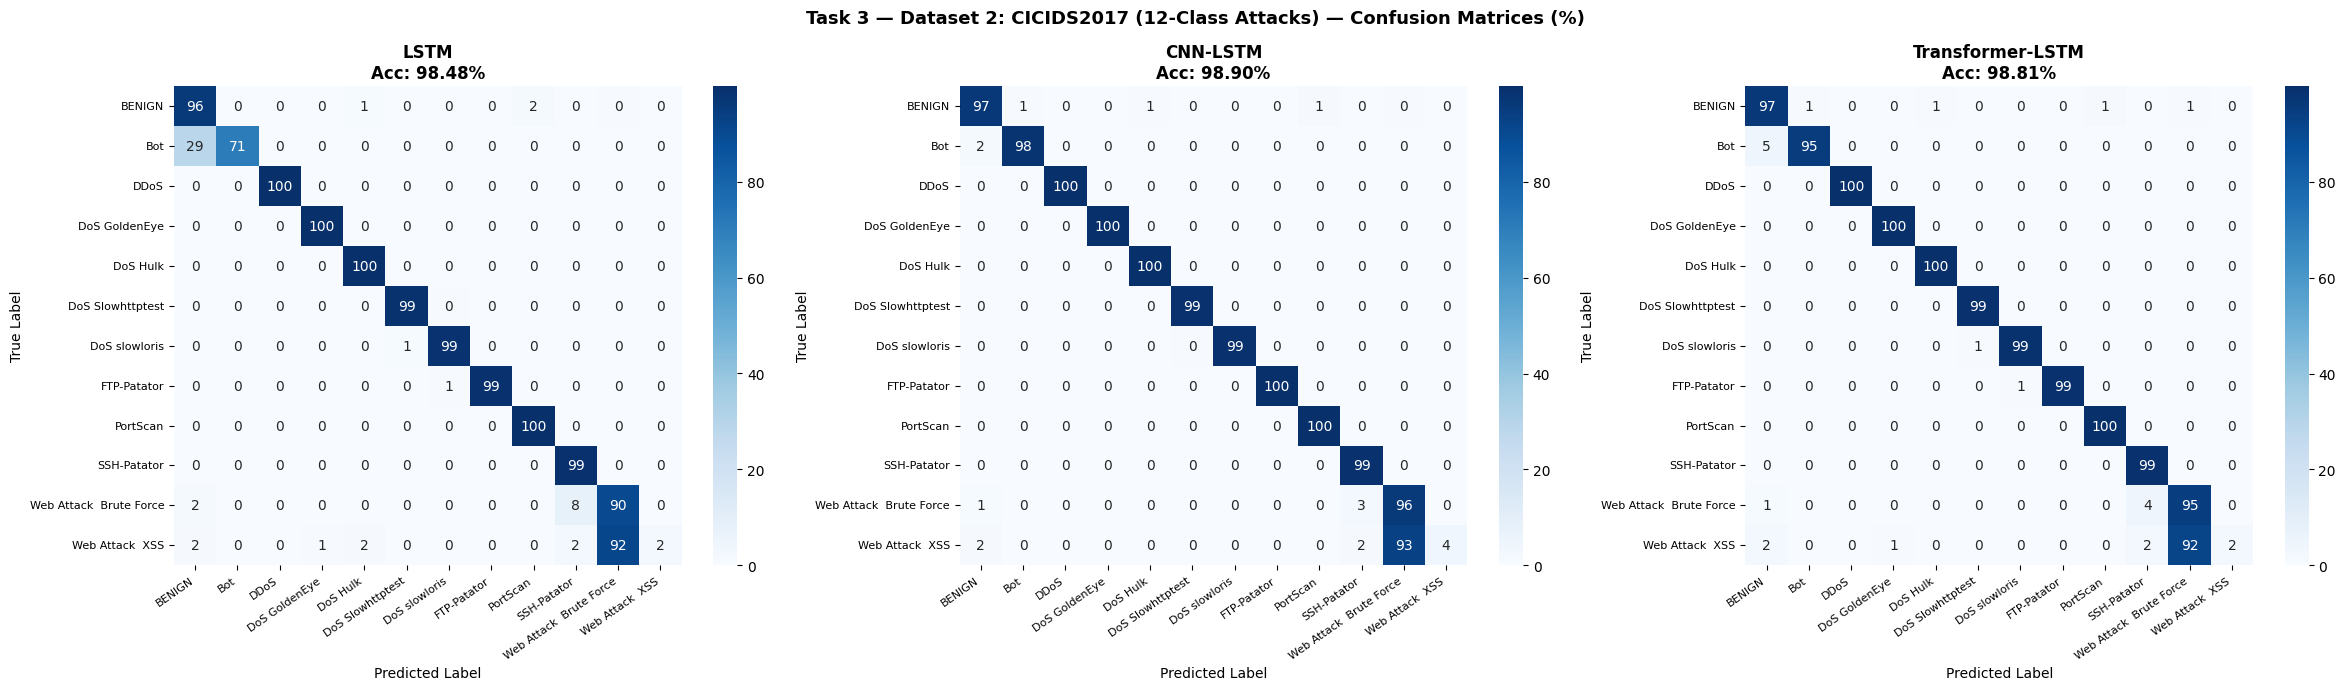

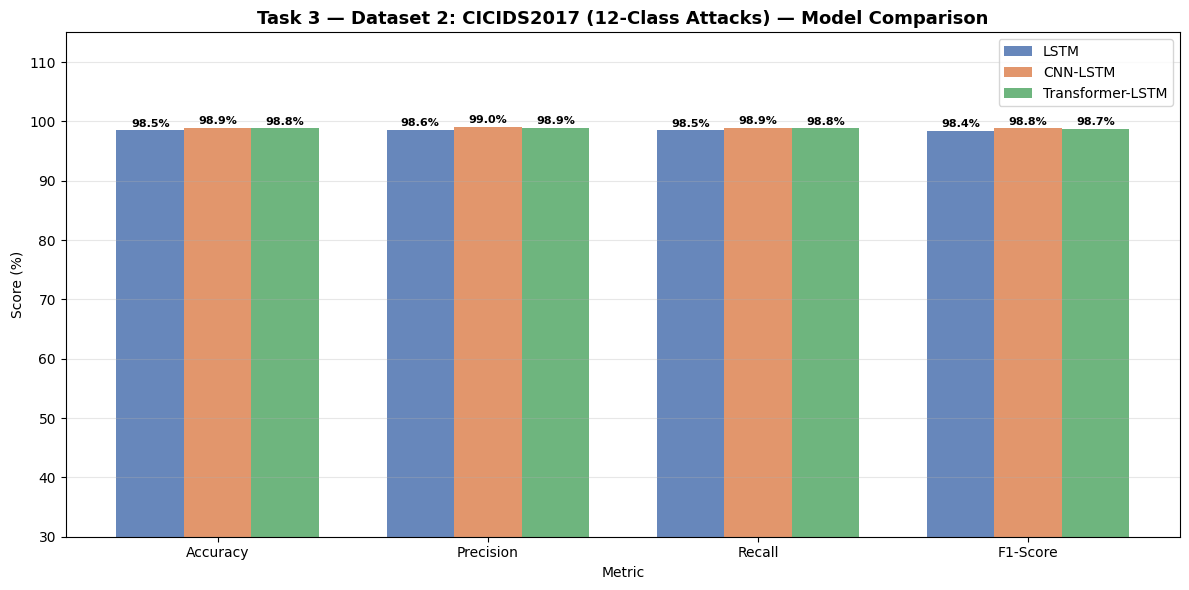


MASTER RESULTS SUMMARY — ALL TASKS & DATASETS

Task 1 — CIC-Darknet2020 (4-class: Tor/VPN):
  Model                    Accuracy  Precision     Recall         F1
  --------------------------------------------------------------
  LSTM                       92.83%     92.78%     92.83%     92.77%
  CNN-LSTM                   94.31%     94.42%     94.31%     94.32%
  Transformer-LSTM           93.57%     93.66%     93.57%     93.58% ★

Task 2 — CIC-Darknet2020 (8-class: App type):
  Model                    Accuracy  Precision     Recall         F1
  --------------------------------------------------------------
  LSTM                       74.24%     74.38%     74.24%     72.11%
  CNN-LSTM                   79.04%     79.33%     79.04%     77.98%
  Transformer-LSTM           76.62%     76.37%     76.62%     74.87% ★

Task 3 — CICIDS2017 (12-class: Attack type):
  Model                    Accuracy  Precision     Recall         F1
  ---------------------------------------------------------

In [18]:
# ============================================================
# CELL 9 (IMPROVED) — Full Evaluation: All 3 Tasks
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

def evaluate_models(models_dict, X_test, y_test, le, task_label, save_prefix):
    results = {}

    print(f"\n{'='*60}")
    print(f"  {task_label}")
    print(f"{'='*60}")

    for name, model in models_dict.items():
        y_prob = model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        results[name] = {'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1-Score': f1}

        print(f"\n  ── {name} ──")
        print(f"  Accuracy : {acc*100:.2f}%  Precision: {prec*100:.2f}%  "
              f"Recall: {rec*100:.2f}%  F1: {f1*100:.2f}%")
        print(classification_report(y_test, y_pred,
                                    target_names=le.classes_, zero_division=0))

    # Confusion matrices
    n = len(models_dict)
    fig, axes = plt.subplots(1, n, figsize=(8*n, 7))
    if n == 1:
        axes = [axes]

    for idx, (name, model) in enumerate(models_dict.items()):
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        cm     = confusion_matrix(y_test, y_pred)
        cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

        annot_fmt = '.1f' if len(le.classes_) <= 8 else '.0f'
        sns.heatmap(cm_pct, annot=True, fmt=annot_fmt, cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_,
                    ax=axes[idx], cbar=True)
        acc = results[name]['Accuracy']
        axes[idx].set_title(f'{name}\nAcc: {acc*100:.2f}%', fontweight='bold')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')
        plt.setp(axes[idx].get_xticklabels(), rotation=35, ha='right', fontsize=8)
        plt.setp(axes[idx].get_yticklabels(), fontsize=8)

    plt.suptitle(f'{task_label} — Confusion Matrices (%)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/{save_prefix}_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bar chart
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    x = np.arange(len(metric_names))
    width = 0.25
    colors = ['#4C72B0', '#DD8452', '#55A868']
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (name, color) in enumerate(zip(results.keys(), colors)):
        vals = [results[name][m]*100 for m in metric_names]
        bars = ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
    ax.set_xlabel('Metric'); ax.set_ylabel('Score (%)')
    ax.set_title(f'{task_label} — Model Comparison', fontweight='bold', fontsize=13)
    ax.set_xticks(x + width); ax.set_xticklabels(metric_names)
    ax.legend(); ax.set_ylim([30, 115]); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/content/{save_prefix}_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    return results

# ── Run all 3 evaluations ─────────────────────────────────────
results_4class = evaluate_models(
    {'LSTM': m1_4, 'CNN-LSTM': m2_4, 'Transformer-LSTM': m3_4},
    X_test_4_lstm, y_test_4, le_4class,
    'Task 1 — Dataset 1: 4-Class (Tor/VPN)', 'task1_4class'
)

results_8class = evaluate_models(
    {'LSTM': m1_8, 'CNN-LSTM': m2_8, 'Transformer-LSTM': m3_8},
    X_test_8_lstm, y_test_8, le_8class,
    'Task 2 — Dataset 1: 8-Class (Application Type)', 'task2_8class'
)

results_cicids = evaluate_models(
    {'LSTM': m1_d2, 'CNN-LSTM': m2_d2, 'Transformer-LSTM': m3_d2},
    X2_test_lstm, y2_test, le_cicids,
    'Task 3 — Dataset 2: CICIDS2017 (12-Class Attacks)', 'task3_cicids'
)

# ── Master summary table ──────────────────────────────────────
print("\n" + "=" * 70)
print("MASTER RESULTS SUMMARY — ALL TASKS & DATASETS")
print("=" * 70)

all_tasks = [
    ("Task 1 — CIC-Darknet2020 (4-class: Tor/VPN)", results_4class),
    ("Task 2 — CIC-Darknet2020 (8-class: App type)", results_8class),
    ("Task 3 — CICIDS2017 (12-class: Attack type)",  results_cicids),
]

for task_name, results in all_tasks:
    print(f"\n{task_name}:")
    print(f"  {'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print(f"  {'-'*62}")
    for name, m in results.items():
        marker = ' ★' if name == 'Transformer-LSTM' else ''
        print(f"  {name:<22} {m['Accuracy']*100:>9.2f}% "
              f"{m['Precision']*100:>9.2f}% "
              f"{m['Recall']*100:>9.2f}% "
              f"{m['F1-Score']*100:>9.2f}%{marker}")

print("\n★ = Proposed model (Transformer-LSTM)")
print("\n✅ All evaluations complete! These are your final results for the report.")
print("\nFiles saved:")
for prefix in ['task1_4class', 'task2_8class', 'task3_cicids']:
    print(f"   /content/{prefix}_confusion.png")
    print(f"   /content/{prefix}_comparison.png")